In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import camb
from camb import model, initialpower
import pickle
import fiducial_parameters as fp
from scipy.interpolate import interp1d
from frb.dm import igm
from scipy.integrate import trapezoid
import astropy.units as u
import h5py
from scipy.optimize import curve_fit
import emcee
import corner
from tqdm import tqdm
import nestle
import dynesty
from dynesty import NestedSampler
from scipy.stats import chi2
import astropy

import pymaster as nmt
import healpy as hp
import wget
import os
from astropy.io import fits

/home/hcwang96/ENV2/lib/python3.10/site-packages/frb/halos/hmf.py:51: UserWarning: hmf_emulator not imported.  Hope you are not intending to use the hmf.py module..
  warnings.warn("hmf_emulator not imported.  Hope you are not intending to use the hmf.py module..")


In [2]:
class dmxgal:
    def __init__(self, FRB_path, gal_path, cat_names, ran_names, zbin_l = [0.05, 0.1, 0.2], zbin_r = [0.1, 0.2, 0.4], lmax = 8000, bin_edges = [1, 10, 20, 30, 40, 67, 115, 196, 333, 565, 960, 1632, 2772, 4709, 8001]):
        self.FRB_path = FRB_path
        self.gal_path = gal_path
        self.cat_names = cat_names
        self.ran_names = ran_names
        assert len(self.cat_names) == len(self.ran_names)
        self.ncat = len(self.cat_names)
        
        self.zbin_l = zbin_l
        self.zbin_r = zbin_r
        assert len(self.zbin_l) == len(self.zbin_r)
        assert len(self.zbin_l) == len(self.cat_names)
        if len(self.zbin_l) == 3:
            self.zbin_notes = 'zall'
        if len(self.zbin_l) == 1:
            zbin_center = (self.zbin_l[0] + self.zbin_r[0])/2
            self.zbin_notes = f'z{zbin_center:.3f}'

        self.lmax = lmax
        self.bin_edges = bin_edges
        if self.bin_edges[-1] != self.lmax+1:
            self.bin_edges[-1] = self.lmax+1
        self.bin = nmt.NmtBin.from_edges(self.bin_edges[:-1], self.bin_edges[1:])
        self.leff = self.bin.get_effective_ells()
        self.bin_num = len(self.leff)

        self.ps = self.measure_ps()

    def read_frb_cat(self, path):
        file = h5py.File(path, 'r')
        l_deg = file["l_deg"][:]
        b_deg = file["b_deg"][:]
        dm_od = file["dm_od"][:]
        w = np.ones_like(l_deg)
        return [l_deg, b_deg], w, dm_od
    
    def read_h5_cat(self, path):
        file = h5py.File(path, 'r')
        l_deg = file["l_deg"][:]
        b_deg = file["b_deg"][:]
        try: 
            w = file['w'][:]
        except KeyError:
            w = np.ones_like(l_deg)
        return [l_deg, b_deg], w
    
    def measure_ps(self):
        
        ps = np.zeros((self.ncat, self.bin_num))
        
        # Not implementing the theory template yet
        #self.theory_cl = np.zeros((self.ncat, self.bin_num))
        #ls = np.arange(self.lmax + 1) # we need from 0 to lmax

        self.frb_pos, self.frb_w, self.frb_dmo = self.read_frb_cat(self.FRB_path)
        self.gal_clu = []
        self.cat_w = []

        for i, (cat_name, ran_name) in enumerate(zip(self.cat_names, self.ran_names)):
            cat_path = self.gal_path + cat_name
            ran_path = self.gal_path + ran_name
            cat_pos, cat_w = self.read_h5_cat(cat_path)
            ran_pos, ran_w = self.read_h5_cat(ran_path)

            print(f"Estimating power spectrum for redshift bin {i}")
        
            # compute the DM-galaxt cross power spectrum using the catalog based estimator
            frb_cat = nmt.NmtFieldCatalog(self.frb_pos, self.frb_w, self.frb_dmo, lmax=self.lmax, lonlat=True)
            gal_clu = nmt.NmtFieldCatalogClustering(cat_pos, cat_w, ran_pos, ran_w, lmax=self.lmax, lonlat=True)
            cat_w = nmt.NmtWorkspace.from_fields(frb_cat, gal_clu, self.bin)
            pcl = nmt.compute_coupled_cell(frb_cat, gal_clu)
            cat_cl = cat_w.decouple_cell(pcl)

            ps[i][:] = cat_cl[0]

            self.gal_clu.append(gal_clu)
            self.cat_w.append(cat_w)

            # get convolved theory prediction, not implemented yet
            #temp = get_theory_temp([self.zbin_l[i]], [self.zbin_r[i]], [self.bg[i]], ls)
            #self.theory_cl[i] = cat_w.decouple_cell(cat_w.couple_cell(temp.cl))[0]

        return ps

    def null_test(self, nsample):
        self.nsample = nsample
        self.rand_ps = np.zeros((self.ncat, self.bin_num, self.nsample))
        
        for zbin in range(self.ncat):

            print(f"Estimating error bar for redshift bin {zbin}")
        
            for i in range(self.nsample):
                
                print(i)
                # randomly permutating FRB DMs while keeping their positions fixed
                f_cat_rand = nmt.NmtFieldCatalog(self.frb_pos, self.frb_w, np.random.permutation(self.frb_dmo), lmax=self.lmax, lonlat=True)
                pcl_rand = nmt.compute_coupled_cell(f_cat_rand, self.gal_clu[zbin])
                
                # no need to recompute the mode coulping matrix since it depends on the masks only which do not change
                #w_fg_rand = nmt.NmtWorkspace.from_fields(f_cat_rand, g_clus, b)
                
                cl_fg_rand = self.cat_w[zbin].decouple_cell(pcl_rand)
                self.rand_ps[zbin, :, i] = cl_fg_rand[0][:]

        self.null_ps_mean = np.mean(self.rand_ps, axis=-1)
        self.error_bar = np.std(self.rand_ps, axis=-1)
        self.null_ps_mean_error = self.error_bar/np.sqrt(self.nsample) # standard deviation of the mean

    def plot_cl_basic(self, figsize = (20, 5), unconvolved = True, exclude = True, style = 'lcl'):

        #uncon_temp = get_theory_temp(self.zbin_l, self.zbin_r, self.bg, self.leff)

        if exclude == True:
            bin_start = 4
        else:
            bin_start = 0
        
        fig, axes = plt.subplots(1, self.ncat, sharey=True, figsize = figsize)

        for i in range(self.ncat):
            
            if style == 'lcl':
            
                axes[i].plot(self.leff[bin_start:], self.leff[bin_start:]*self.ps[i][bin_start:], label = f"z = {self.zbin_l[i]} to {self.zbin_r[i]}", color = f'C{i}', linestyle = 'dotted', marker=".")
                axes[i].hlines(0,0,self.lmax, color = 'black', linestyle = 'dashed')
                
                # Not implementing the theory curve yet
                #axes[i].plot(self.leff, self.theory_cl[i], 'r--', label = f"theory convolved")
                #if unconvolved:
                #    axes[i].plot(self.leff, uncon_temp.cl[i], ':', label = f"theory", color = "gray")
    
                axes[i].set_xscale("log")
                axes[i].set_xlabel(r'$\ell$', fontsize=15)
                axes[i].set_ylabel(r'$\ell C_\ell [cm^{-3} pc]$', fontsize=15)
                axes[i].legend()

            if style == 'cl':
                axes[i].plot(self.leff[bin_start:], self.ps[i][bin_start:], label = f"z = {self.zbin_l[i]} to {self.zbin_r[i]}", color = f'C{i}', linestyle = 'dotted', marker=".")
                axes[i].hlines(0,0,self.lmax, color = 'black', linestyle = 'dashed')
                axes[i].set_xscale("log")
                axes[i].set_yscale("log")
                axes[i].set_xlabel(r'$\ell$', fontsize=15)
                axes[i].set_ylabel(r'$C_\ell [cm^{-3} pc]$', fontsize=15)
                axes[i].legend()

            if style == 'l(l+1)cl':
                axes[i].plot(self.leff[bin_start:], self.leff[bin_start:]*(self.leff[bin_start:]+1)*self.ps[i][bin_start:], label = f"z = {self.zbin_l[i]} to {self.zbin_r[i]}", color = f'C{i}', linestyle = 'dotted', marker=".")
                axes[i].hlines(0,0,self.lmax, color = 'black', linestyle = 'dashed')
                axes[i].set_xscale("log")
                axes[i].set_xlabel(r'$\ell$', fontsize=15)
                axes[i].set_ylabel(r'$\ell (\ell + 1) C_\ell [cm^{-3} pc]$', fontsize=15)
                axes[i].legend()

    def plot_null_ps(self, figsize = (20, 5), exclude = False, style ='l(l+1)cl'):

        if exclude == True:
            bin_start = 4
        else:
            bin_start = 0
    
        fig, axes = plt.subplots(1, self.ncat, sharey=True, figsize = figsize)

        for i in range(self.ncat):
            
            if style == 'lcl':
        
                axes[i].errorbar(self.leff[bin_start:], self.leff[bin_start:]*self.null_ps_mean[i][bin_start:], yerr=self.leff[bin_start:]*self.null_ps_mean_error[i][bin_start:], capsize=2, marker=".",
                                 label = f"z = {self.zbin_l[i]} to {self.zbin_r[i]}, null", color = f'C{i}', linestyle = 'none')
                axes[i].hlines(0,0,self.lmax, color = 'black', linestyle = 'dashed')
                axes[i].set_xscale("log")
                axes[i].set_xlabel(r'$\ell$', fontsize=15)
                axes[i].set_ylabel(r'$\ell C_\ell [cm^{-3} pc]$', fontsize=15)
                axes[i].legend()

            if style == 'cl':
                axes[i].errorbar(self.leff[bin_start:], self.null_ps_mean[i][bin_start:], yerr=self.null_ps_mean_error[i][bin_start:], capsize=2, marker=".", label = f"z = {self.zbin_l[i]} to {self.zbin_r[i]}", color = f'C{i}', linestyle = 'none')
                axes[i].hlines(0,0,self.lmax, color = 'black', linestyle = 'dashed')
                axes[i].set_xscale("log")
                axes[i].set_yscale("log")
                axes[i].set_xlabel(r'$\ell$', fontsize=15)
                axes[i].set_ylabel(r'$C_\ell [cm^{-3} pc]$', fontsize=15)
                axes[i].legend()
            
            if style == 'l(l+1)cl':
        
                axes[i].errorbar(self.leff[bin_start:], self.leff[bin_start:]*(self.leff[bin_start:] + 1)*self.null_ps_mean[i][bin_start:], yerr=self.leff[bin_start:]*(self.leff[bin_start:] + 1)*self.null_ps_mean_error[i][bin_start:],
                                 capsize=2, marker=".", label = f"z = {self.zbin_l[i]} to {self.zbin_r[i]}, null", color = f'C{i}', linestyle = 'none')
                axes[i].hlines(0,0,self.lmax, color = 'black', linestyle = 'dashed')
                axes[i].set_xscale("log")
                axes[i].set_xlabel(r'$\ell$', fontsize=15)
                axes[i].set_ylabel(r'$\ell (\ell + 1) C_\ell [cm^{-3} pc]$', fontsize=15)
                axes[i].legend()

    def plot_cl_err(self, figsize = (20, 5), unconvolved = True, exclude = True, style = 'lcl'):
        
        if exclude == True:
            bin_start = 4
        else:
            bin_start = 0
        
        fig, axes = plt.subplots(1, self.ncat, sharey=True, figsize = figsize)

        for i in range(self.ncat):
            
            if style == 'lcl':
            
                axes[i].errorbar(self.leff[bin_start:], self.leff[bin_start:]*self.ps[i][bin_start:], yerr=self.leff[bin_start:]*self.error_bar[i][bin_start:], capsize=2, marker=".",
                                 label = f"z = {self.zbin_l[i]} to {self.zbin_r[i]}", color = f'C{i}', linestyle = 'none')
                axes[i].hlines(0,0,self.lmax, color = 'black', linestyle = 'dashed')
                axes[i].set_xscale("log")
                axes[i].set_xlabel(r'$\ell$', fontsize=15)
                axes[i].set_ylabel(r'$\ell C_\ell [cm^{-3} pc]$', fontsize=15)
                axes[i].set_ylim(-2, 2.4)
                axes[i].legend()

            if style == 'cl':
                axes[i].errorbar(self.leff[bin_start:], self.ps[i][bin_start:], yerr=self.error_bar[i][bin_start:], capsize=2, marker=".", label = f"z = {self.zbin_l[i]} to {self.zbin_r[i]}", color = f'C{i}', linestyle = 'none')
                axes[i].hlines(0,0,self.lmax, color = 'black', linestyle = 'dashed')
                axes[i].set_xscale("log")
                axes[i].set_yscale("log")
                axes[i].set_xlabel(r'$\ell$', fontsize=15)
                axes[i].set_ylabel(r'$C_\ell [cm^{-3} pc]$', fontsize=15)
                axes[i].legend()

            if style == 'l(l+1)cl':
                axes[i].errorbar(self.leff[bin_start:], self.leff[bin_start:]*(self.leff[bin_start:]+1)*self.ps[i][bin_start:], yerr=self.leff[bin_start:]*(self.leff[bin_start:]+1)*self.error_bar[i][bin_start:], capsize=2, marker=".",
                                 label = f"z = {self.zbin_l[i]} to {self.zbin_r[i]}", color = f'C{i}', linestyle = 'none')
                axes[i].hlines(0,0,self.lmax, color = 'black', linestyle = 'dashed')
                axes[i].set_xscale("log")
                axes[i].set_xlabel(r'$\ell$', fontsize=15)
                axes[i].set_ylabel(r'$\ell (\ell + 1) C_\ell [cm^{-3} pc]$', fontsize=15)
                axes[i].legend()

    def save(self, notes =''):

        outname = f"dmxgal_lmax{self.lmax}_bin{self.bin_num}_{self.zbin_notes}{notes}.h5"
        file = h5py.File(outname, 'w')
        file.create_dataset('lmax', data = self.lmax)
        file.create_dataset('bin_edges', data = self.bin_edges)
        file.create_dataset('bin_centers', data = self.leff)
        file.create_dataset('zbin_l', data = self.zbin_l)
        file.create_dataset('zbin_r', data = self.zbin_r)
        file.create_dataset('cl', data = self.ps)
        file.create_dataset('error', data = self.error_bar)
        file.create_dataset('null_cl_mean', data = self.null_ps_mean)
        file.create_dataset('null_cl_error', data = self.null_ps_mean_error)
        file.close()

class read_dmxgal(dmxgal):
    def __init__(self, file_paths):

        # file_paths can contain multiple files. They should be ordered by redshift bins.
        
        self.file_paths = file_paths
        self.nfile = len(file_paths)
        self.zbin_l = []
        self.zbin_r = []
        self.ps = []
        self.error_bar = []
        self.null_ps_mean = []
        self.null_ps_mean_error = []
        
        for i in range(self.nfile):
            file = h5py.File(self.file_paths[i], 'r')
            
            if i == 0:
                self.lmax = file['lmax'][()]
                self.bin_edges = file['bin_edges'][:]
                self.leff = file['bin_centers'][:]
                self.bin_num = len(self.leff)

            self.zbin_l.extend(file['zbin_l'][:])
            self.zbin_r.extend(file['zbin_r'][:])
            self.ps.extend(file['cl'][:])
            self.error_bar.extend(file['error'][:])
            self.null_ps_mean.extend(file['null_cl_mean'][:])
            self.null_ps_mean_error.extend(file['null_cl_error'][:])

        self.ncat = len(self.zbin_l)

# Read the null test results

In [3]:
file_paths3 = ['dmxgal_lmax8000_bin14_z0.075_nsample1000.h5', 'dmxgal_lmax8000_bin14_z0.150_nsample1000.h5', 'dmxgal_lmax8000_bin14_z0.250_nsample1000.h5', 'dmxgal_lmax8000_bin14_z0.350_nsample1000.h5', 'dmxgal_lmax8000_bin14_z0.450_nsample1000.h5']
n = read_dmxgal(file_paths3)

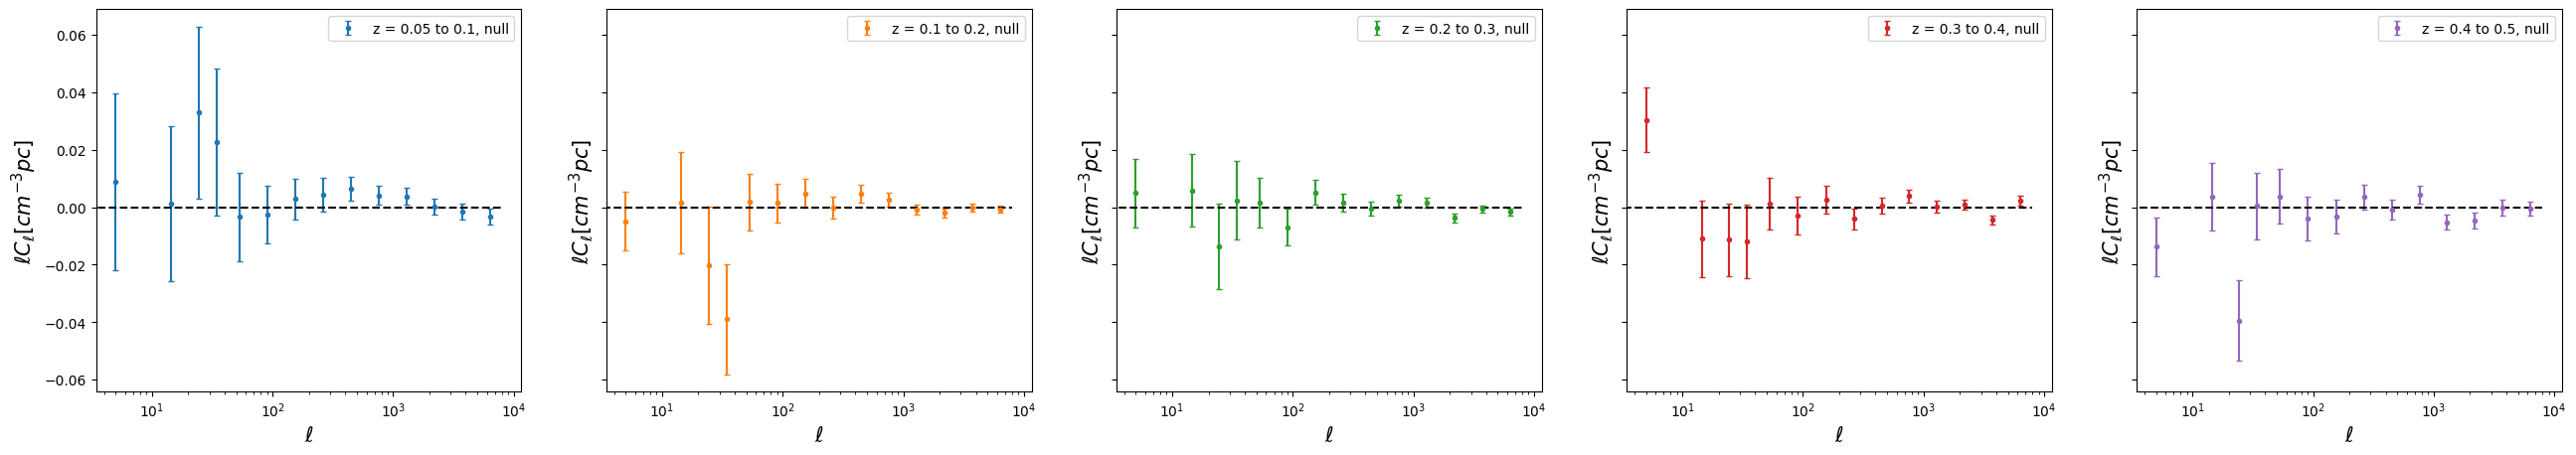

In [4]:
n.plot_null_ps(exclude = False, style = 'lcl', figsize = (32, 5))

# Small-scale perturbation

In [5]:
class small_scale_pert:
    def __init__(self, FRB_path, gal_path, cat_names, ran_names, ps_path):
        '''
        Make sure that the redshift ranges of cat_names and ran_names correspond to those of ps_path.
        The code won't check for this.
        '''
        self.FRB_path = FRB_path
        self.gal_path = gal_path
        self.cat_names = cat_names
        self.ran_names = ran_names
        assert len(self.cat_names) == len(self.ran_names)
        self.ncat = len(self.cat_names)
        self.ps_path = ps_path

        self.read_ps_results(self.ps_path)
        
        assert len(self.zbin_l) == len(self.zbin_r)
        assert len(self.zbin_l) == len(self.cat_names)
        if len(self.zbin_l) == 5:
            self.zbin_notes = 'zall'
        if len(self.zbin_l) == 1:
            zbin_center = (self.zbin_l[0] + self.zbin_r[0])/2
            self.zbin_notes = f'z{zbin_center:.3f}'

        self.bin = nmt.NmtBin.from_edges(self.bin_edges[:-1], self.bin_edges[1:])
        assert all(self.leff == self.bin.get_effective_ells())

    def read_ps_results(self, path):

        file = h5py.File(path, 'r')
        self.lmax = file['lmax'][()]
        self.bin_edges = file['bin_edges'][:]
        self.leff = file['bin_centers'][:]
        self.zbin_l = file['zbin_l'][:]
        self.zbin_r = file['zbin_r'][:]
        self.ps = file['cl'][:]
        self.error_bar = file['error'][:]

        self.bin_num = len(self.leff)
        assert self.bin_num == len(self.bin_edges) - 1
        
    def read_frb_cat(self, path):
        
        file = h5py.File(path, 'r')
        l_deg = file["l_deg"][:]
        b_deg = file["b_deg"][:]
        dm_od = file["dm_od"][:]
        w = np.ones_like(l_deg)
        
        return [l_deg, b_deg], w, dm_od

    def read_frb_cat_ra_dec(self, path):
        
        file = h5py.File(path, 'r')
        ra_deg = file["ra_deg"][:]
        dec_deg = file["dec_deg"][:]
        
        return ra_deg, dec_deg
    
    def read_h5_cat(self, path):
        
        file = h5py.File(path, 'r')
        l_deg = file["l_deg"][:]
        b_deg = file["b_deg"][:]
        try: 
            w = file['w'][:]
        except KeyError:
            w = np.ones_like(l_deg)
            
        return [l_deg, b_deg], w

    def bin_pert(self, npert = 100, bin_start = 5):

        self.npert = npert
        self.bin_start = bin_start
        assert self.bin_start >= 1
        assert self.bin_start <= self.bin_num

        self.frb_pos, self.frb_w, self.frb_dmo = self.read_frb_cat(self.FRB_path)
        self.frb_ra, self.frb_dec = self.read_frb_cat_ra_dec(self.FRB_path)
        
        self.rand_ps_pert_ra = np.zeros((self.ncat, self.bin_num, self.npert))
        self.pert_ra_range = 180/self.bin_edges[self.bin_start - 1] # degrees
        nf = len(self.frb_ra)

        for zbin, (cat_name, ran_name) in enumerate(zip(self.cat_names, self.ran_names)):
            cat_path = self.gal_path + cat_name
            ran_path = self.gal_path + ran_name
            cat_pos, cat_w = self.read_h5_cat(cat_path)
            ran_pos, ran_w = self.read_h5_cat(ran_path)
            g_clus = nmt.NmtFieldCatalogClustering(cat_pos, cat_w, ran_pos, ran_w, lmax=self.lmax, lonlat=True)

            print(f"Estimating power spectrum for redshift bin {zbin}")
        
            for i in range(self.npert):
                print(i)
                ran_ra = np.random.uniform(-1*self.pert_ra_range, self.pert_ra_range, nf)
                ra_deg_pert = (self.frb_ra + ran_ra/np.cos(np.radians(self.frb_dec)))%360
                coord_pert = astropy.coordinates.SkyCoord(ra=ra_deg_pert, dec=self.frb_dec, frame='icrs', unit='deg')
                coord_pert = coord_pert.galactic
                pos_f_pert_ra = np.array([coord_pert.l.deg, coord_pert.b.deg]) 
                f_cat_pert_ra = nmt.NmtFieldCatalog(pos_f_pert_ra, self.frb_w, self.frb_dmo, lmax=self.lmax, lonlat=True)
                w_fg_pert_ra = nmt.NmtWorkspace.from_fields(f_cat_pert_ra, g_clus, self.bin)
                pcl_fg_pert_ra = nmt.compute_coupled_cell(f_cat_pert_ra, g_clus)
                cl_fg_pert_ra = w_fg_pert_ra.decouple_cell(pcl_fg_pert_ra)
                self.rand_ps_pert_ra[zbin, :,i] = cl_fg_pert_ra[0][:]

        self.rand_ps_pert_ra_mean = np.mean(self.rand_ps_pert_ra, axis=-1)
        self.rand_ps_mean_error = np.std(self.rand_ps_pert_ra, axis=-1)/np.sqrt(self.npert) # standard deviation of the mean

    def save(self, notes =''):

        outname = f"dmxgal_lmax{self.lmax}_bin{self.bin_num}_{self.zbin_notes}_npert{self.npert}{notes}_ra_pert.h5"
        file = h5py.File(outname, 'w')
        file.create_dataset('lmax', data = self.lmax)
        file.create_dataset('bin_edges', data = self.bin_edges)
        file.create_dataset('bin_centers', data = self.leff)
        file.create_dataset('zbin_l', data = self.zbin_l)
        file.create_dataset('zbin_r', data = self.zbin_r)
        file.create_dataset('error', data = self.error_bar)
        file.create_dataset('ps_pert_mean', data = self.rand_ps_pert_ra_mean)
        file.create_dataset('ps_pert_mean_error', data = self.rand_ps_mean_error)
        file.create_dataset('npert', data = self.npert)
        file.create_dataset('bin_start', data = self.bin_start)
        file.close()

    def plot_mean_rand_ps(self, figsize = (32/5, 5), exclude = False, orientation = 'horizontal', error = 'ps_error'):
        
        assert (error == 'ps_error') or (error == 'mean_error')
        
        if exclude == True:
            bin_start = 4
        else:
            bin_start = 0

        assert (orientation == 'horizontal') or (orientation == 'vertical')
        if orientation == 'horizontal':        
            f, ax = plt.subplots(1, self.ncat, sharey=True, figsize=figsize)
        if orientation == 'vertical':
            f, ax = plt.subplots(self.ncat, 1, sharex=True, figsize=figsize)
        axes = np.atleast_1d(ax)

        for i in range(self.ncat):
            
            if error == 'ps_error':
                axes[i].errorbar(self.leff[bin_start:], self.leff[bin_start:]*self.rand_ps_pert_ra_mean[i][bin_start:], yerr=self.leff[bin_start:]*self.error_bar[i][bin_start:], capsize=2, marker=".",
                                 label = f"z = {self.zbin_l[i]} to {self.zbin_r[i]}", color = f'C{i}', linestyle = 'none')
            if error == 'mean_error':
                axes[i].errorbar(self.leff[bin_start:], self.leff[bin_start:]*self.rand_ps_pert_ra_mean[i][bin_start:], yerr=self.leff[bin_start:]*self.rand_ps_mean_error[i][bin_start:], capsize=2, marker=".",
                                 label = f"z = {self.zbin_l[i]} to {self.zbin_r[i]}", color = f'C{i}', linestyle = 'none')
            axes[i].vlines(self.bin_edges[self.bin_start - 1],-2, 2.5, color = 'gray', linestyle = 'dashed')
            axes[i].hlines(0,0,self.lmax, color = 'black', linestyle = 'dashed')
            axes[i].set_xscale("log")
            axes[i].set_xlabel(r'$\ell$', fontsize=15)
            axes[i].set_ylabel(r'$\ell C_\ell [cm^{-3} pc]$', fontsize=15)
            axes[i].set_ylim(-2, 2.4)
            axes[i].legend()

class read_small_scale_pert(small_scale_pert):
    def __init__(self, file_paths):

        # file_paths can contain multiple files. They should be ordered by redshift bins.
        
        self.file_paths = file_paths
        self.nfile = len(file_paths)
        self.zbin_l = []
        self.zbin_r = []
        self.error_bar = []
        self.rand_ps_pert_ra_mean = []
        self.rand_ps_mean_error = []
        
        for i in range(self.nfile):
            file = h5py.File(self.file_paths[i], 'r')
            
            if i == 0:
                self.lmax = file['lmax'][()]
                self.bin_edges = file['bin_edges'][:]
                self.leff = file['bin_centers'][:]
                self.bin_num = len(self.leff)
                self.bin_start = file['bin_start'][()]

            self.zbin_l.extend(file['zbin_l'][:])
            self.zbin_r.extend(file['zbin_r'][:])
            self.error_bar.extend(file['error'][:])
            self.rand_ps_pert_ra_mean.extend(file['ps_pert_mean'][:])
            self.rand_ps_mean_error.extend(file['ps_pert_mean_error'][:])

        self.ncat = len(self.zbin_l)

In [6]:
dir_path = './small_scale_pert_3/'
files = ['dmxgal_lmax8000_bin14_z0.075_npert1000_ra_pert.h5', 'dmxgal_lmax8000_bin14_z0.150_npert1000_ra_pert.h5', 'dmxgal_lmax8000_bin14_z0.250_npert1000_ra_pert.h5', 'dmxgal_lmax8000_bin14_z0.350_npert1000_ra_pert.h5', 'dmxgal_lmax8000_bin14_z0.450_npert1000_ra_pert.h5']
file_path = [dir_path + files[i] for i in range(5)]

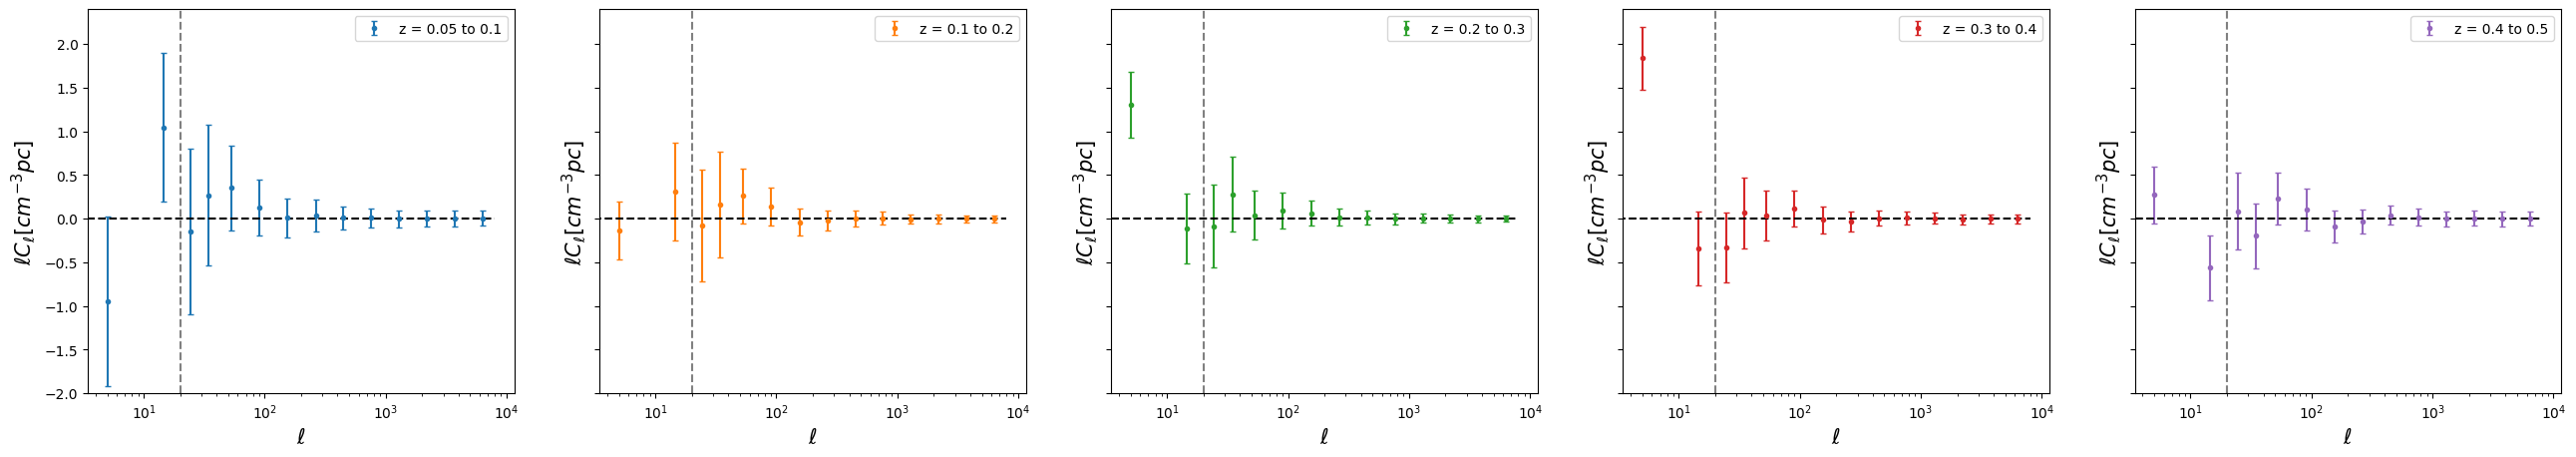

In [7]:
s = read_small_scale_pert(file_path)
s.plot_mean_rand_ps(figsize = (32, 5))

In [8]:
180/s.bin_edges[2]

9.0

# Galactic DM null test results

In [9]:
FRB_path = "/project/ctb-vkaspi/hcwang96/dmxgal/final/1_FRB_catalog/cat_II_Gal_dm_overd_repeater_once_100NE2001_inclusion.h5" 
gal_path = "/lustre06/project/6034496/hcwang96/dmxgal/checks/2_Galaxy_catalog/DESI_LIS/DR8/north/"
cat_names = ["DESI_LIS_BGS_north_z_0.05_0.1.h5", "DESI_LIS_BGS_north_z_0.1_0.2.h5", "DESI_LIS_BGS_north_z_0.2_0.3.h5", "DESI_LIS_BGS_north_z_0.3_0.4.h5", "DESI_LIS_BGS_north_z_0.4_0.5.h5"]
ran_names = ["DESI_LIS_BGS_north_ran_all_z_v2.h5", "DESI_LIS_BGS_north_ran_all_z_v2.h5", "DESI_LIS_BGS_north_ran_all_z_v2.h5", "DESI_LIS_BGS_north_ran_all_z_v2.h5", "DESI_LIS_BGS_north_ran_all_z_v2.h5"]

In [10]:
g = dmxgal(FRB_path, gal_path, cat_names, ran_names, zbin_l = [0.05, 0.1, 0.2, 0.3, 0.4], zbin_r = [0.1, 0.2, 0.3, 0.4, 0.5])

Estimating power spectrum for redshift bin 0
Estimating power spectrum for redshift bin 1
Estimating power spectrum for redshift bin 2
Estimating power spectrum for redshift bin 3
Estimating power spectrum for redshift bin 4


In [11]:
import types

def read_error_bar(self, ps_paths):

    self.zbin_l
    self.zbin_r
    self.error_bar = []

    assert len(ps_paths) == self.ncat
        
    for i in range(self.ncat):
        file = h5py.File(ps_paths[i], 'r')
            
        assert self.lmax == file['lmax'][()]
        assert all(self.bin_edges == file['bin_edges'][:])
        assert all(self.leff == file['bin_centers'][:])
        assert self.zbin_l[i] == file['zbin_l'][0]
        assert self.zbin_r[i] == file['zbin_r'][0]

        self.error_bar.extend(file['error'][:])

g.read_error_bar = types.MethodType(read_error_bar, g)

In [12]:
ps_files = ['./dmxgal_lmax8000_bin14_z0.075_nsample1000.h5', './dmxgal_lmax8000_bin14_z0.150_nsample1000.h5', './dmxgal_lmax8000_bin14_z0.250_nsample1000.h5', './dmxgal_lmax8000_bin14_z0.350_nsample1000.h5', './dmxgal_lmax8000_bin14_z0.450_nsample1000.h5']
g.read_error_bar(ps_files)

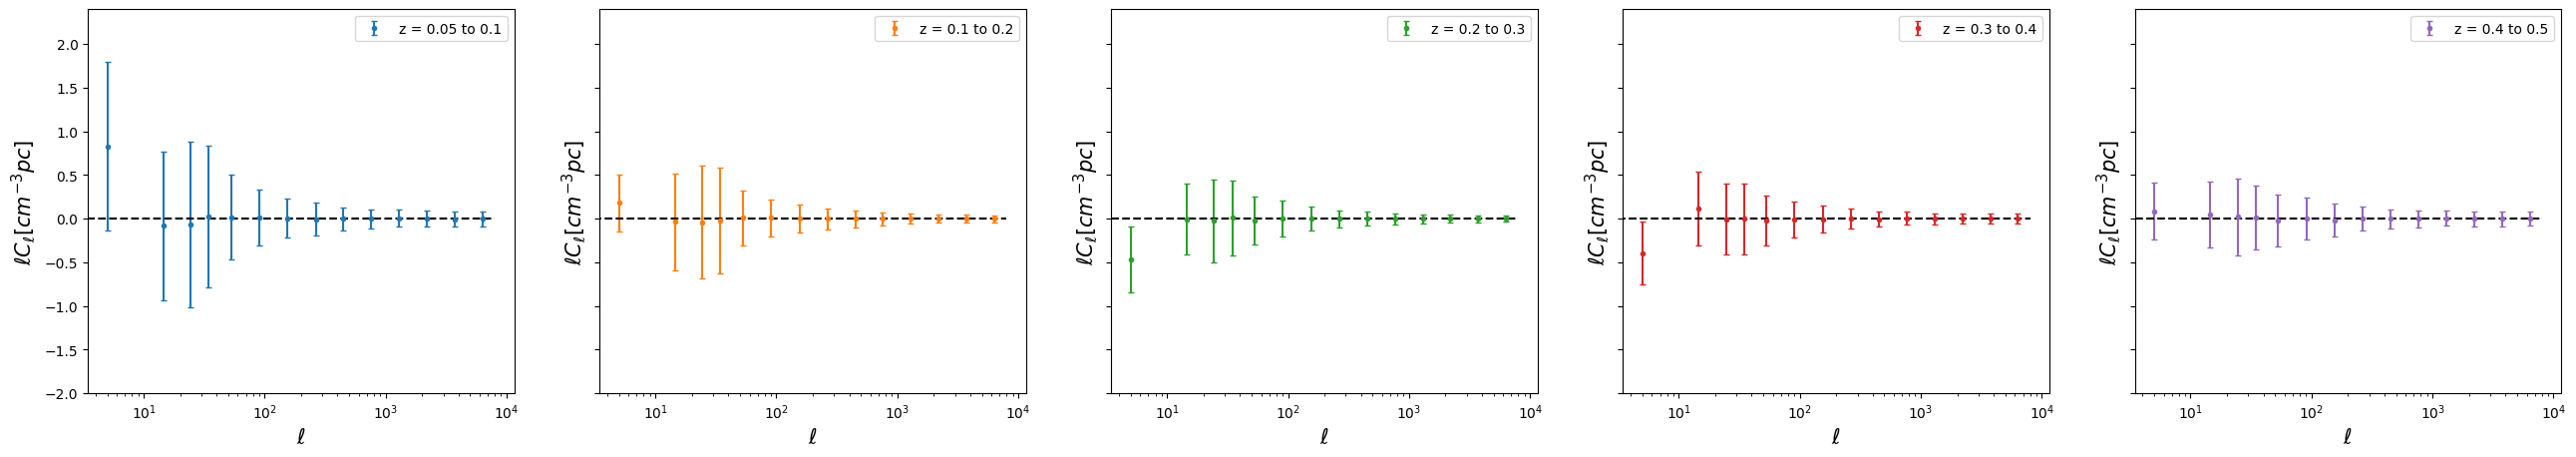

In [13]:
g.plot_cl_err(exclude = False, style = 'lcl', figsize = (32, 5))

# Combining the three results

In [14]:
def plot_all_null_test(figsize = (32, 15), ylim_up = 1.6, ylim_low = -1, save = False, name = 'null_tests'):

    ncat = 5
    bin_start = 0
    vbin = 4
    factor = np.sqrt(1000)
    font = 18
    label_font = 22
    zs = [0.075, 0.150, 0.250, 0.350, 0.450]
    f, axes = plt.subplots(3, ncat, sharex=True, sharey = True, figsize=figsize)

    for i in range(n.ncat):
                
        axes[0, i].errorbar(n.leff[bin_start:], n.leff[bin_start:]*n.null_ps_mean[i][bin_start:]*factor, yerr=n.leff[bin_start:]*n.null_ps_mean_error[i][bin_start:]*factor, capsize=4, marker="o",# label = f"z = {zs[i]:.3f}, null",
                                color = f'C{0}', linestyle = 'none', elinewidth=2.5)
        axes[0, i].vlines(n.bin_edges[vbin],-2, 2.5, color = 'gray', linestyle = 'dashed')
        axes[0, i].hlines(0,0, n.lmax, color = 'black', linestyle = 'dashed')
        axes[0, i].set_xscale("log")
        #axes[0, i].set_xlabel(r'$\ell$', fontsize=15)
        if i == 0:
            axes[0, i].set_ylabel(r'$ \sqrt{N} \, \ell C_\ell \text{  } [\text{pc } \text{cm}^{-3}]$', fontsize=label_font)
        axes[0, i].set_ylim(ylim_low, ylim_up)
        axes[0, i].set_xlim(3, 8000)
        #axes[0, i].legend(fontsize=font)
        axes[0, i].tick_params(axis="both", labelsize=font)
        axes[0, i].set_title(rf"$z_g$ = {zs[i]:.3f}",  fontsize=label_font)
        axes[0, i].tick_params(axis="y", direction="in", which="both")

    for i in range(g.ncat):
            
        axes[1, i].errorbar(g.leff[bin_start:], g.leff[bin_start:]*g.ps[i][bin_start:], yerr=g.leff[bin_start:]*g.error_bar[i][bin_start:], capsize=4, marker="o",# label = f"z = {zs[i]:.3f}, G_DM null",
                                 color = f'C{0}', linestyle = 'none', elinewidth=2.5)
        axes[1, i].vlines(g.bin_edges[vbin],-2, 2.5, color = 'gray', linestyle = 'dashed')
        axes[1, i].hlines(0,0, g.lmax, color = 'black', linestyle = 'dashed')
        axes[1, i].set_xscale("log")
        #axes[1, i].set_xlabel(r'$\ell$', fontsize=15)
        if i == 0:
            axes[1, i].set_ylabel(r'$\ell C_\ell \text{  } [\text{pc } \text{cm}^{-3}]$', fontsize=label_font)
        axes[1, i].set_ylim(ylim_low, ylim_up)
        #axes[1, i].legend(fontsize=font)
        axes[1, i].tick_params(axis="both", labelsize=font)
        axes[1, i].tick_params(axis="y", direction="in", which="both")

    for i in range(s.ncat):

        axes[2, i].errorbar(s.leff[bin_start:], s.leff[bin_start:]*s.rand_ps_pert_ra_mean[i][bin_start:], yerr=s.leff[bin_start:]*s.error_bar[i][bin_start:], capsize=4, marker="o",# label = f"z = {zs[i]:.3f}, RA pert",
                                 color = f'C{0}', linestyle = 'none', elinewidth=2.5)
        axes[2, i].vlines(s.bin_edges[vbin],-2, 2.5, color = 'gray', linestyle = 'dashed')
        axes[2, i].hlines(0,0,s.lmax, color = 'black', linestyle = 'dashed')
        axes[2, i].set_xscale("log")
        axes[2, i].set_xlabel(r'$\ell$', fontsize=label_font)
        if i == 0:
            axes[2, i].set_ylabel(r'$\ell C_\ell \text{  } [\text{pc } \text{cm}^{-3}]$', fontsize=label_font)
        axes[2, i].set_ylim(ylim_low, ylim_up)
        #axes[2, i].legend(fontsize=font)
        axes[2, i].tick_params(axis="both", labelsize=font)
        axes[2, i].tick_params(axis="y", direction="in", which="both")

    axes[0,0].text(
            x=0.95, y=0.95,  # Relative position inside subplot (normalized coords)
            s="(a) DM Jackknife",
            fontsize=label_font,
            color="black",
            ha="right",  # Right-align text
            va="top",  # Align text to the top
            transform=axes[0,0].transAxes  # Uses subplot-relative coordinates
        )

    axes[1,0].text(
            x=0.95, y=0.95,  # Relative position inside subplot (normalized coords)
            s="(b) Galactic DM",
            fontsize=label_font,
            color="black",
            ha="right",  # Right-align text
            va="top",  # Align text to the top
            transform=axes[1,0].transAxes  # Uses subplot-relative coordinates
        )

    axes[2,0].text(
            x=0.95, y=0.95,  # Relative position inside subplot (normalized coords)
            s="(c) FRB RA Perturbed",
            fontsize=label_font,
            color="black",
            ha="right",  # Right-align text
            va="top",  # Align text to the top
            transform=axes[2,0].transAxes  # Uses subplot-relative coordinates
        )
        
    f.tight_layout()
    f.subplots_adjust(wspace=0)
    if save:
        name += '.pdf'
        f.savefig(name,bbox_inches='tight')

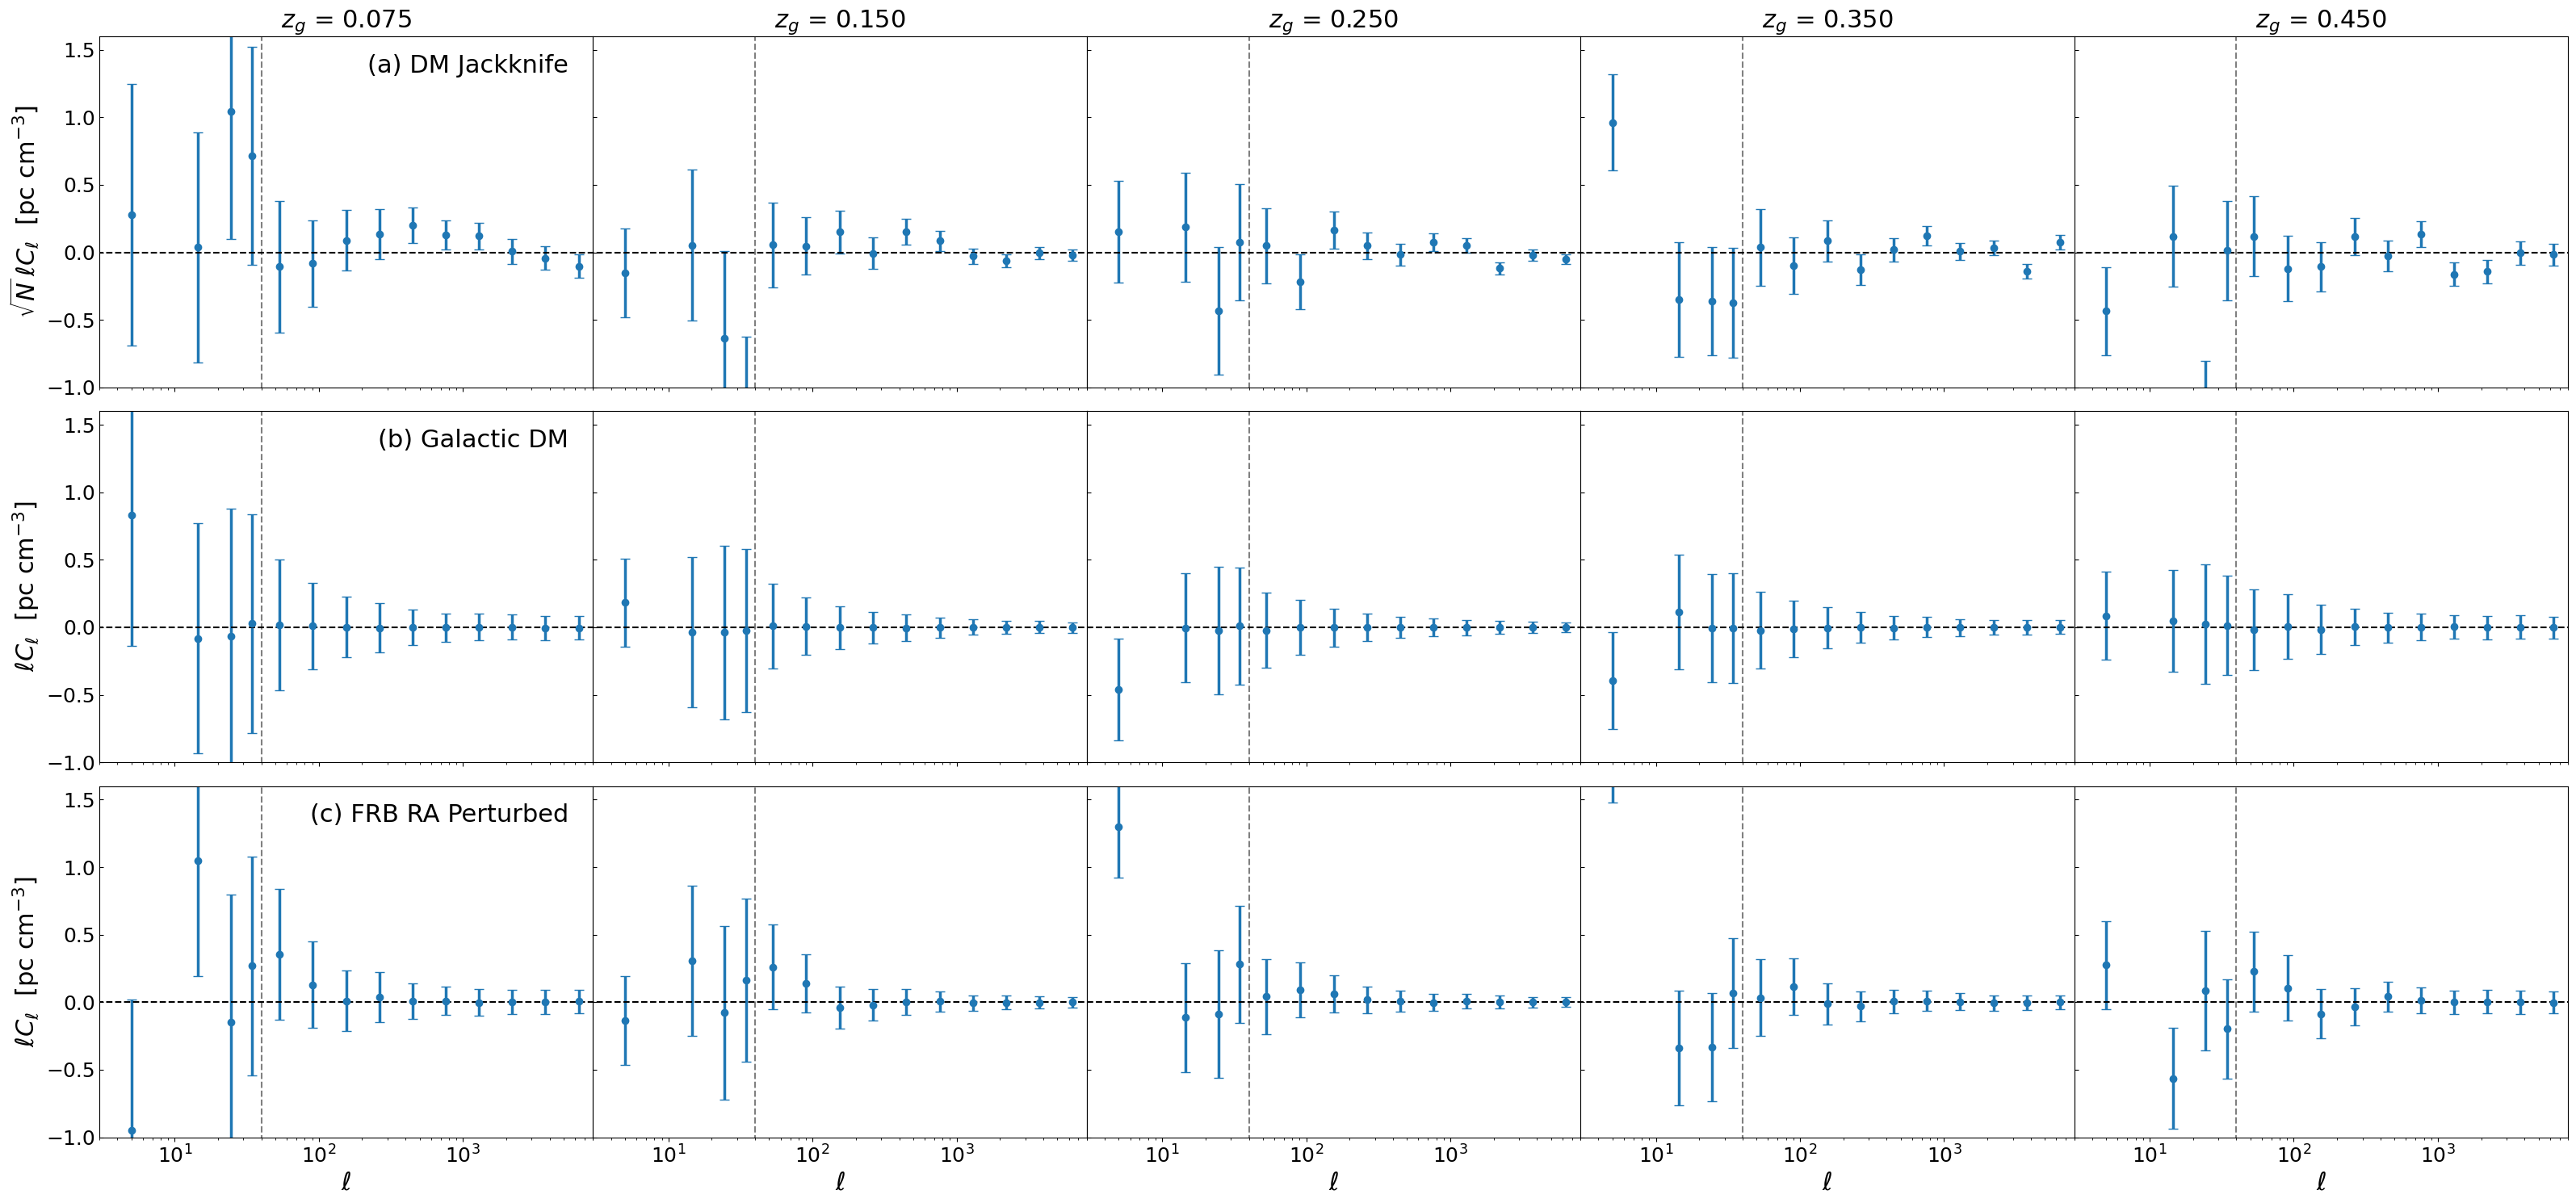

In [15]:
plot_all_null_test(ylim_up = 1.6, ylim_low = -1, save = True, name = 'fig_5_new_cat_2')

In [16]:
def plot_all_null_test_2(figsize = (32, 5), ylim_up = 1.6, ylim_low = -1, save = False, name = 'null_tests', nplot = 0):

    ncat = 5
    bin_start = 0
    vbin = 4
    factor = np.sqrt(1000)
    font = 18
    label_font = 22
    zs = [0.075, 0.150, 0.250, 0.350, 0.450]
    f, axes = plt.subplots(1, ncat, sharex=True, sharey = True, figsize=figsize)

    if nplot == 0:
        for i in range(n.ncat):
                    
            axes[i].errorbar(n.leff[bin_start:], n.leff[bin_start:]*n.null_ps_mean[i][bin_start:]*factor, yerr=n.leff[bin_start:]*n.null_ps_mean_error[i][bin_start:]*factor, capsize=4, marker="o",# label = f"z = {zs[i]:.3f}, null",
                                    color = f'C{0}', linestyle = 'none', elinewidth=2.5)
            axes[i].vlines(n.bin_edges[vbin],-2, 2.5, color = 'gray', linestyle = 'dashed')
            axes[i].hlines(0,0, n.lmax, color = 'black', linestyle = 'dashed')
            axes[i].set_xscale("log")
            #axes[0, i].set_xlabel(r'$\ell$', fontsize=15)
            if i == 0:
                axes[i].set_ylabel(r'$ \sqrt{N} \, \ell C_\ell \text{  } [\text{pc } \text{cm}^{-3}]$', fontsize=label_font)
            axes[i].set_ylim(ylim_low, ylim_up)
            axes[i].set_xlim(3, 8000)
            #axes[0, i].legend(fontsize=font)
            axes[i].tick_params(axis="both", labelsize=font)
            axes[i].set_title(rf"$z_g$ = {zs[i]:.3f}",  fontsize=label_font)
            axes[i].tick_params(axis="y", direction="in", which="both")

    if nplot == 1:
        for i in range(g.ncat):
                
            axes[i].errorbar(g.leff[bin_start:], g.leff[bin_start:]*g.ps[i][bin_start:], yerr=g.leff[bin_start:]*g.error_bar[i][bin_start:], capsize=4, marker="o",# label = f"z = {zs[i]:.3f}, G_DM null",
                                     color = f'C{0}', linestyle = 'none', elinewidth=2.5)
            axes[i].vlines(g.bin_edges[vbin],-2, 2.5, color = 'gray', linestyle = 'dashed')
            axes[i].hlines(0,0, g.lmax, color = 'black', linestyle = 'dashed')
            axes[i].set_xscale("log")
            #axes[1, i].set_xlabel(r'$\ell$', fontsize=15)
            if i == 0:
                axes[i].set_ylabel(r'$\ell C_\ell \text{  } [\text{pc } \text{cm}^{-3}]$', fontsize=label_font)
            axes[i].set_ylim(ylim_low, ylim_up)
            axes[i].set_xlim(3, 8000)
            #axes[1, i].legend(fontsize=font)
            axes[i].tick_params(axis="both", labelsize=font)
            axes[i].set_title(rf"$z_g$ = {zs[i]:.3f}",  fontsize=label_font)
            axes[i].tick_params(axis="y", direction="in", which="both")

    if nplot == 2:
        for i in range(s.ncat):
    
            axes[i].errorbar(s.leff[bin_start:], s.leff[bin_start:]*s.rand_ps_pert_ra_mean[i][bin_start:], yerr=s.leff[bin_start:]*s.error_bar[i][bin_start:], capsize=4, marker="o",# label = f"z = {zs[i]:.3f}, RA pert",
                                     color = f'C{0}', linestyle = 'none', elinewidth=2.5)
            axes[i].vlines(s.bin_edges[vbin],-2, 2.5, color = 'gray', linestyle = 'dashed')
            axes[i].hlines(0,0,s.lmax, color = 'black', linestyle = 'dashed')
            axes[i].set_xscale("log")
            axes[i].set_xlabel(r'$\ell$', fontsize=label_font)
            if i == 0:
                axes[i].set_ylabel(r'$\ell C_\ell \text{  } [\text{pc } \text{cm}^{-3}]$', fontsize=label_font)
            axes[i].set_ylim(ylim_low, ylim_up)
            axes[i].set_xlim(3, 8000)
            #axes[2, i].legend(fontsize=font)
            axes[i].tick_params(axis="both", labelsize=font)
            axes[i].set_title(rf"$z_g$ = {zs[i]:.3f}",  fontsize=label_font)
            axes[i].tick_params(axis="y", direction="in", which="both")

        
    f.tight_layout()
    f.subplots_adjust(wspace=0)

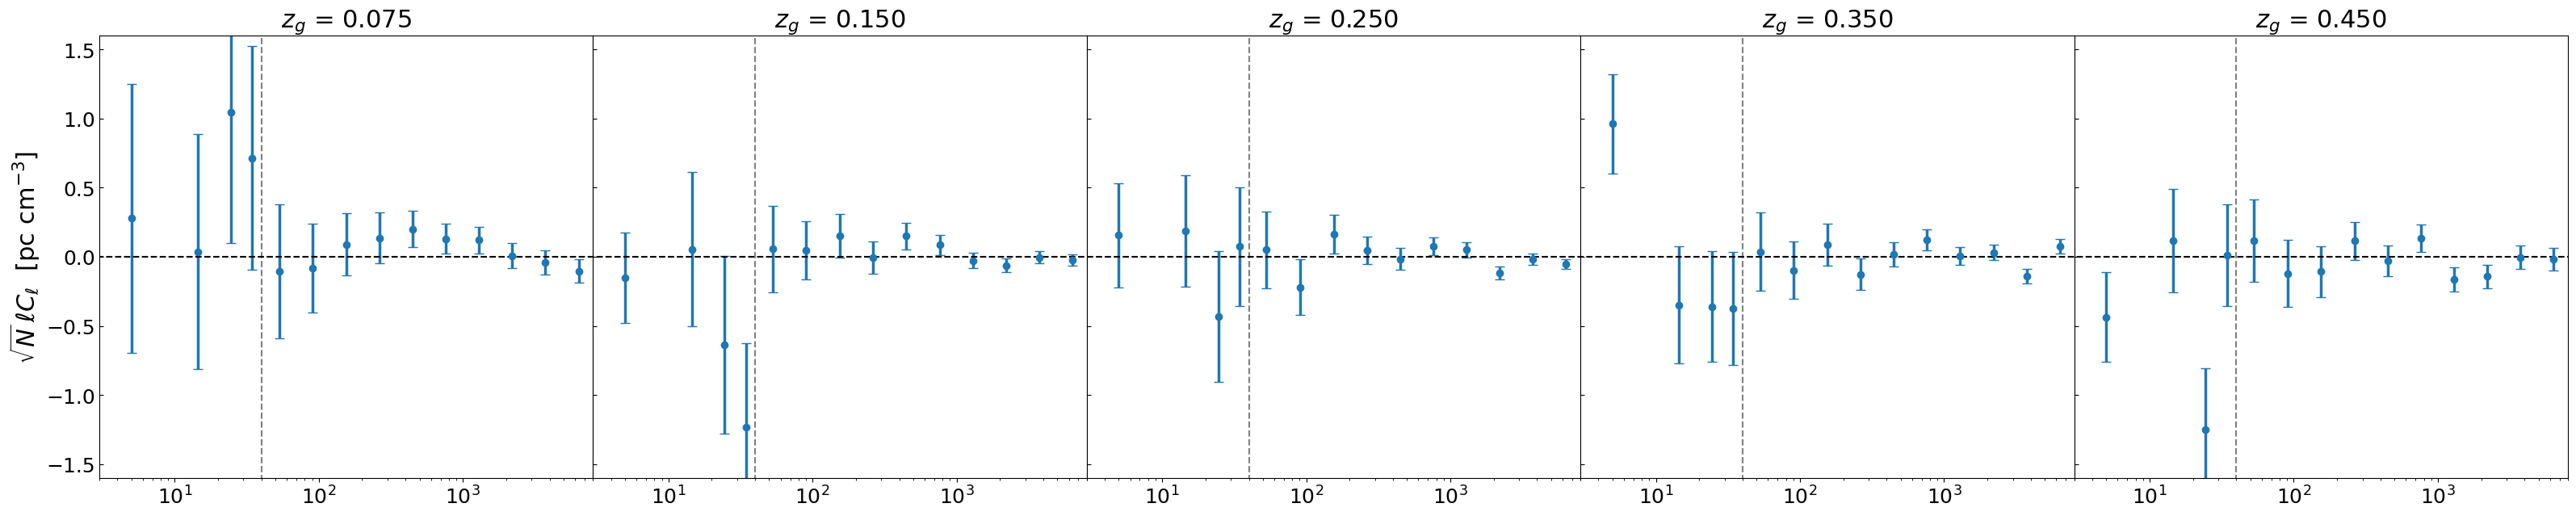

In [17]:
plot_all_null_test_2(figsize = (32, 6.5), ylim_up = 1.6, ylim_low = -1.6, save = False, name = 'updated_fig_5', nplot = 0)

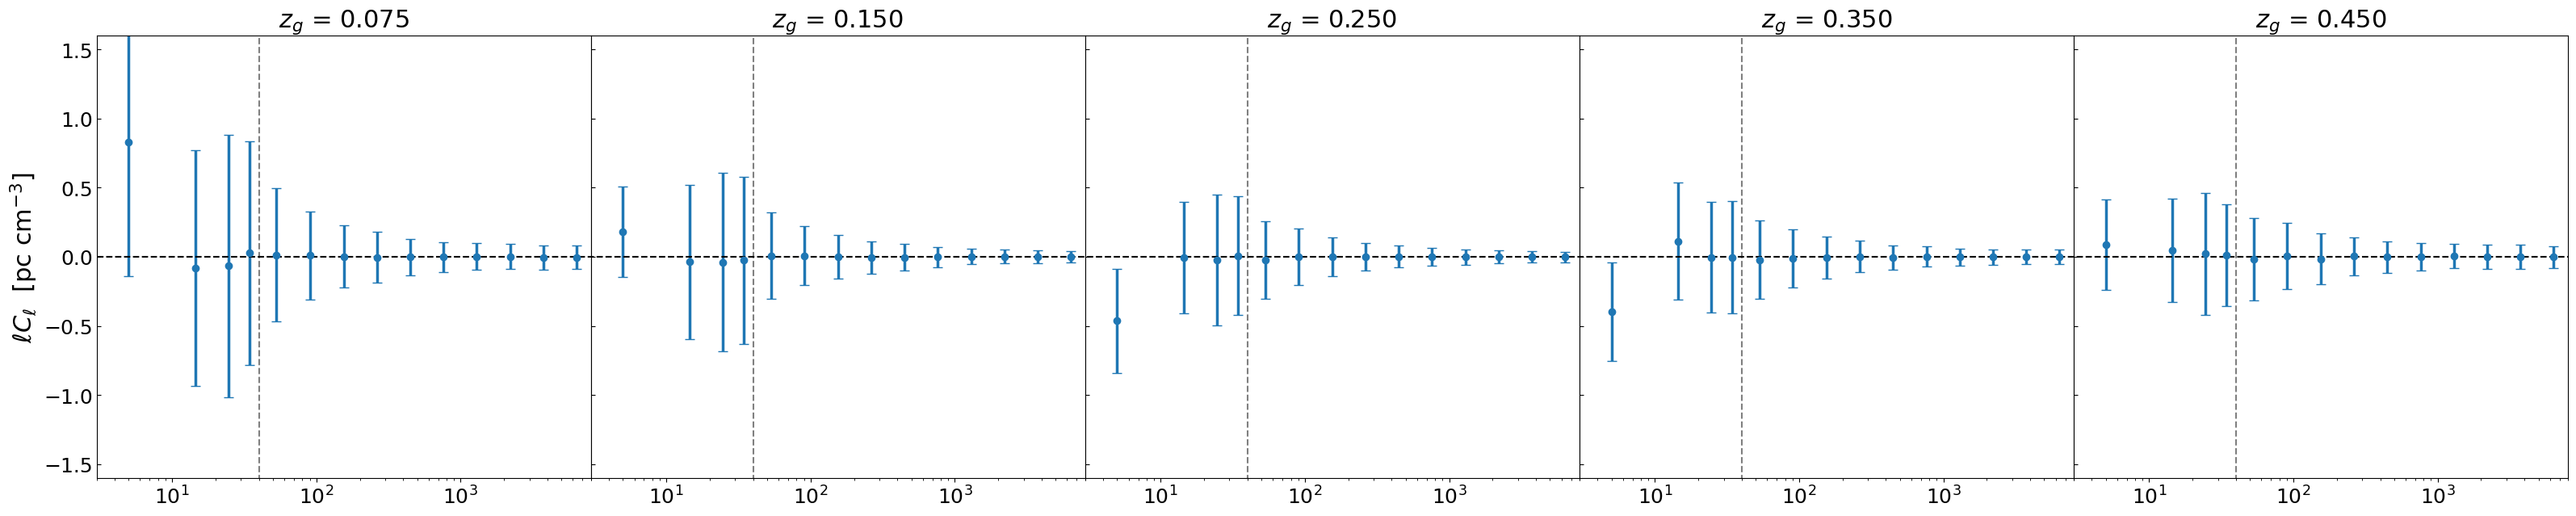

In [18]:
plot_all_null_test_2(figsize = (32, 6.5), ylim_up = 1.6, ylim_low = -1.6, save = False, name = 'updated_fig_5', nplot = 1)

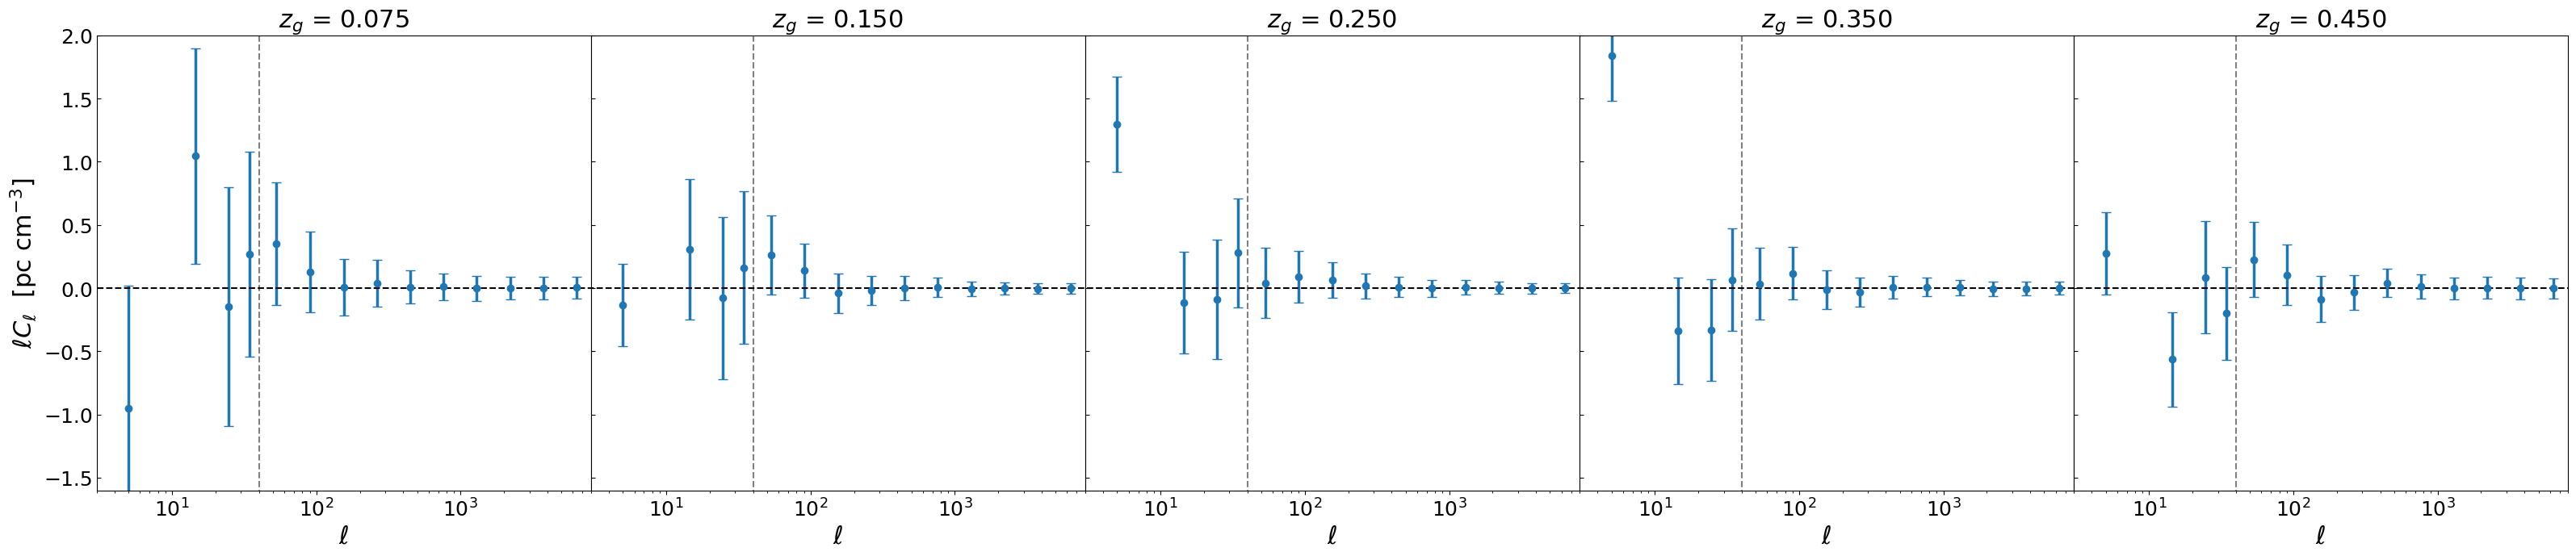

In [19]:
plot_all_null_test_2(figsize = (32, 7), ylim_up = 2, ylim_low = -1.6, save = False, name = 'updated_fig_5', nplot = 2)